In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
from utils.cart import make_wcs, to_cart

In [5]:
cmap = 'RdBu_r'

In [6]:
! nvidia-smi

zsh:1: command not found: nvidia-smi


## _Fermi_ data

In [7]:
from scipy.interpolate import interp1d

In [12]:
from astropy.io import fits

counts_fits = fits.open("../data/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data),int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [13]:
exposure = fits.open("../data/exposure_ultracleanveto_bestpsf_joined.fits")
exposure = exposure[0].data[:, int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = exposure.shape[1] // upsample_factor

In [14]:
e_min_interp = np.array(counts_fits[1].data[:])['E_MIN'] / 1e3

In [15]:
exposure_interp = interp1d(e_min_interp, exposure, axis=0)
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) 
exposure_interp = exposure_interp(e_bins).reshape(len(e_bins), -1, upsample_factor, b, upsample_factor).mean((-1, -3))

## Templates

In [16]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [17]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [18]:
np.max(counts_downsampled[~mask_roi])

278

## Zenodo

In [19]:
from astropy.io import fits

In [20]:
import pandas as pd
dif_names = pd.read_csv('/Users/smsharma/Downloads/ZENODO_FILES/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat', skiprows=1, header=None, delim_whitespace=True)[1].tolist()
dif_names = dif_names[:]

In [21]:
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) / 1e3 
e_bins_widths = (e_bins[1:] - e_bins[:-1])
e_bins_centers = (e_bins[1:] + e_bins[:-1]) / 2

In [22]:
# Select energy bins closest to 2 and 20 GeV
e_bin_min_idx = np.argmin(np.abs(e_bins - 2)) #- 1
e_bin_max_idx = np.argmin(np.abs(e_bins - 20)) #- 1

In [25]:
pixel_size_data = 0.25
pixel_size_target = 0.5
extent = 25
upsample_factor = int(pixel_size_target / pixel_size_data)

In [26]:
dif = dif_names[0]

temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

for dif_type in ['bremss', 'pi0', 'ICS']:
    file = fits.open("/Users/smsharma/Downloads/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
    phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
    n_pix_edge = int((30 - extent) / pixel_size_data)
    n_pix_total = int(2 * extent / pixel_size_data)
    phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
    b = phi.shape[1] // upsample_factor
    phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
    phi *= np.deg2rad(pixel_size_target ** 2)
    phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
    phi /= 1e3
    temp_ary.append(phi[:, ::-1])
    
temp_ary = np.array(temp_ary)
temp_ary.mean((1,2))

array([1.329005  , 1.85003303, 1.00300816, 1.19548247, 0.92873186,
       1.54008749, 2.32903186, 2.53250726])

## Poisson fits

In [27]:
from scipy.optimize import minimize

In [28]:
from scipy.stats import poisson

def likelihood(theta, data, mask=None):
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ik, i -> k", temp_ary[:, ~mask], theta)
    return -poisson.logpmf(data[~mask], temp_sum).mean()

def likelihood_map(theta, data, mask=None):
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ikj, i -> kj", temp_ary, theta)
    return poisson.logpmf(data, temp_sum) * ~mask

## With ROI mask

In [29]:
from tqdm import tqdm

In [30]:
ll_list = []
opt_list = []
ll_map_list = []

for dif in tqdm(dif_names):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'bremss', 'ICS']:
        file = fits.open("/Users/smsharma/Downloads/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target ** 2)
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        phi /= 1e3
        temp_ary.append(phi[:, ::-1])

    temp_ary = np.array(temp_ary)

    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
    ll_data = - opt.fun
    ll_map = likelihood_map(opt.x, counts_downsampled, mask_roi)
    
    opt_list.append(opt)
    ll_list.append(ll_data) 
    ll_map_list.append(ll_map)

100%|██████████| 80/80 [01:04<00:00,  1.23it/s]


In [31]:
np.array([opt_list[i].x[0] for i in range(len(dif_names))])[np.argmax(np.array(ll_list) * (~mask_roi).sum())]

1.039760524792802

In [32]:
# plt.plot(np.array([opt_list[i].x[0] for i in range(len(dif_names))]))

In [33]:
temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_dif_cart])
ll_p6 = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])
ll_mO = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

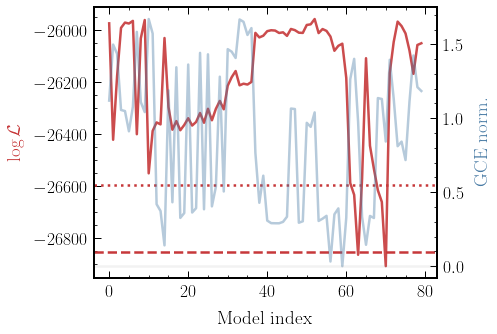

In [34]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list) * (~mask_roi).sum())
ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='dashed')
ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls='dotted')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

## Quadrants

In [35]:
ll_list_quadrants = []
opt_list_quadrants = []
ll_map_list_quadrants = []

for dif in tqdm(dif_names):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'bremss', 'ICS']:
        file = fits.open("/Users/smsharma/Downloads/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target ** 2)
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        phi /= 1e3
        phi = phi[:, ::-1]
        
        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[:int(n_pixels / 2), :int(n_pixels / 2)] = phi[:int(n_pixels / 2), :int(n_pixels / 2)]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[:int(n_pixels / 2), int(n_pixels / 2):] = phi[:int(n_pixels / 2), int(n_pixels / 2):]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[int(n_pixels / 2):, :int(n_pixels / 2)] = phi[int(n_pixels / 2):, :int(n_pixels / 2)]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[int(n_pixels / 2):, int(n_pixels / 2):] = phi[int(n_pixels / 2):, int(n_pixels / 2):]
        temp_ary.append(temp_temp_dif)
    
    temp_ary = np.array(temp_ary)

    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
    ll_data = - opt.fun
    ll_map = likelihood_map(opt.x, counts_downsampled, mask_roi)

    opt_list_quadrants.append(opt)
    ll_list_quadrants.append(ll_data) 
    ll_map_list_quadrants.append(ll_map) 

100%|██████████| 80/80 [05:14<00:00,  3.94s/it]


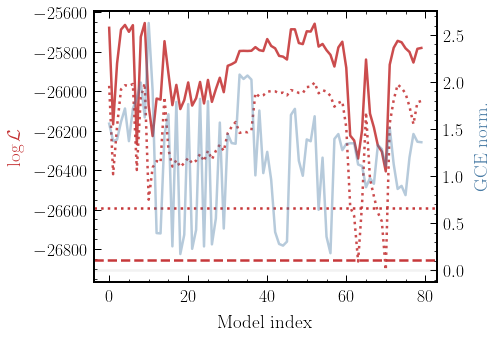

In [36]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list_quadrants) * (~mask_roi).sum())
ax1.plot(np.array(ll_list) * (~mask_roi).sum(), ls='dotted', color=cols_default[0])
ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='dashed')
ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls='dotted')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

## Likelihood maps

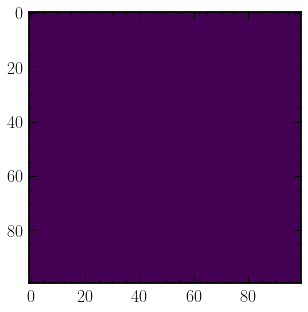

In [46]:
bad_pixels = np.zeros((100, 100))

for ll_map in ll_map_list_quadrants:
    test_mask = ll_map < -100000
    bad_pixels += test_mask
    
bad_pixels = bad_pixels > 0 
plt.imshow(bad_pixels)

In [47]:
ll_list_quadrants_badexcluded = []
for ll_map in ll_map_list_quadrants:
    ll_list_quadrants_badexcluded.append(ll_map.flatten()[~bad_pixels.flatten()].sum())

Text(0.5, 1.0, 'Best fit model')

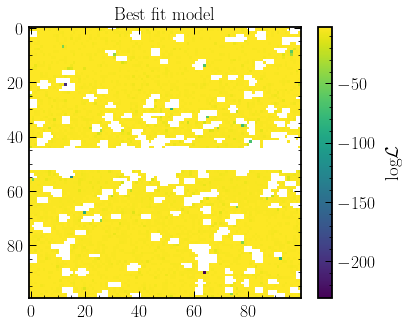

In [81]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmax(np.array(ll_list_quadrants))], mask_roi > 0 ))
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Best fit model")

Text(0.5, 1.0, 'Worst fit model')

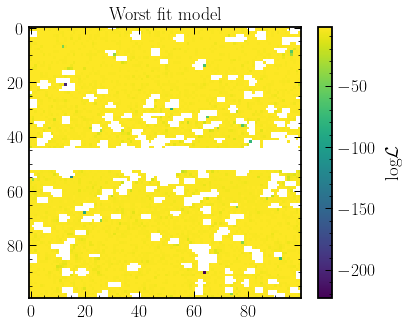

In [82]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmin(np.array(ll_list_quadrants))], mask_roi > 0 ))
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Worst fit model")

Text(0.5, 1.0, 'Difference')

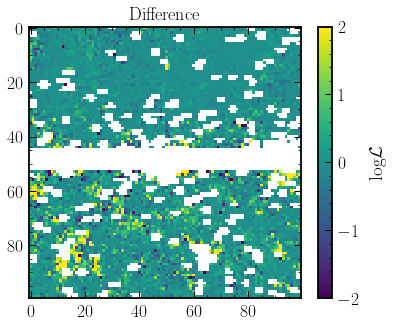

In [69]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmax(np.array(ll_list_quadrants))] - ll_map_list_quadrants[np.argmin(np.array(ll_list_quadrants))], mask_roi > 0 ), vmin=-2, vmax=2)
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Difference")

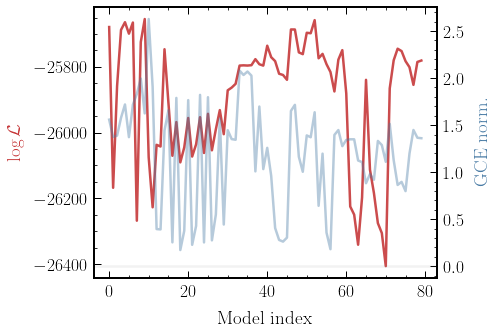

In [66]:
fig, ax1 = plt.subplots()

ax1.plot(ll_list_quadrants_badexcluded)

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

## Spherical harmonics

In [70]:
from scipy.special import sph_harm

def Ylm(l, m, theta, phi): 
    """
    Redefine spherical harmonics from scipy.special
    to match physics convention.
    
    Parameters
    ----------
    l : int, array_like
        Degree of the harmonic (int); ``l >= 0``.
    m : int, array_like
        Order of the harmonic (int); ``|m| <= l``.
    theta : array_like
        Polar (colatitudinal) coordinate; must be in ``[0, pi]``.
    phi : array_like
        Azimuthal (longitudinal) coordinate; must be in ``[0, 2*pi]``.
    
    Returns
    -------
    Ylm : complex float
       The harmonic Ylm sampled at ``theta`` and ``phi``.
    """
    if np.abs(m) > l:
        Ylm = 0
    else:
        Ylm = sph_harm(m, l, phi, theta) # Perform redefinition, scipy version
    return Ylm


In [83]:
nside = 128

lmax = 3

sph_harm_temps = []
for l in np.arange(0, lmax + 1):
    for m in np.arange(-l, l + 1):
        sph_harm_temp = to_cart(np.real(Ylm(l, m, *hp.pix2ang(nside, np.arange(hp.nside2npix(nside))))), n_pixels=n_pixels, pixelsize=pixelsize)
        sph_harm_temps.append(sph_harm_temp)

ERROR! Session/line number was not unique in database. History logging moved to new session 1043


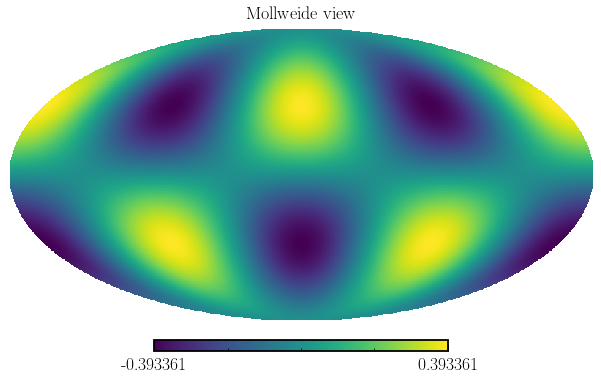

In [89]:
hp.mollview(np.real(Ylm(3, 2, *hp.pix2ang(nside, np.arange(hp.nside2npix(nside))))))

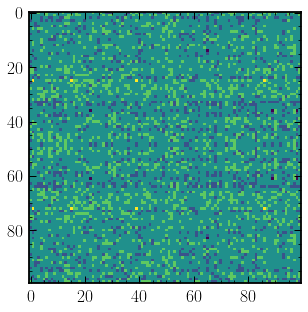

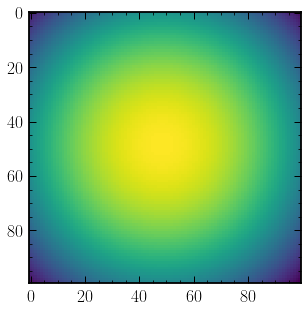

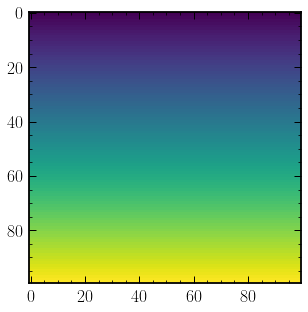

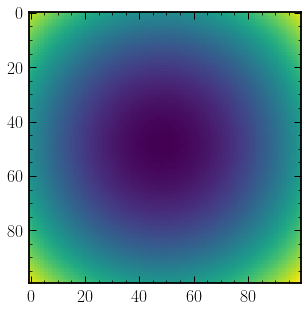

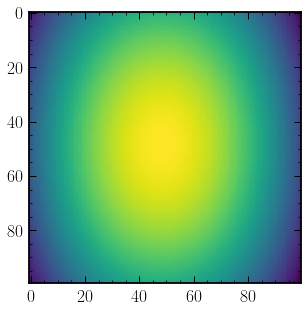

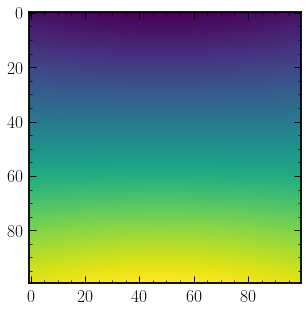

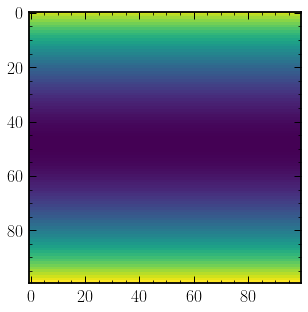

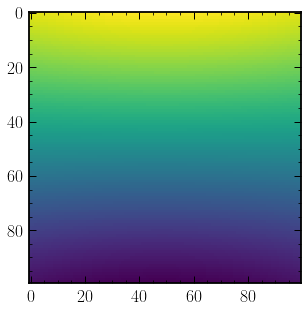

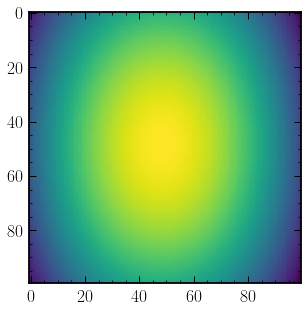

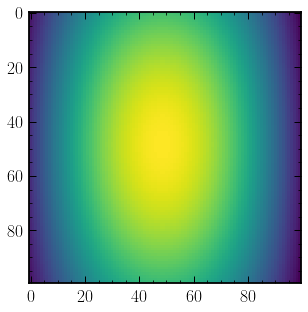

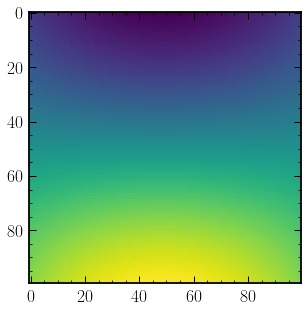

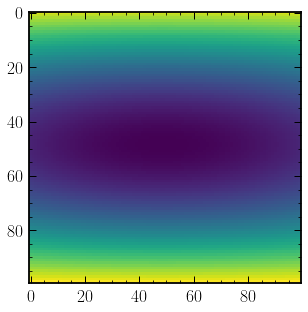

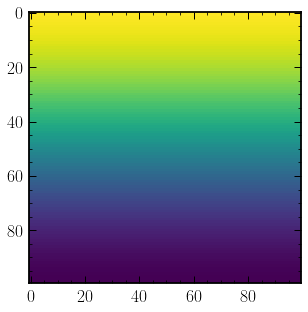

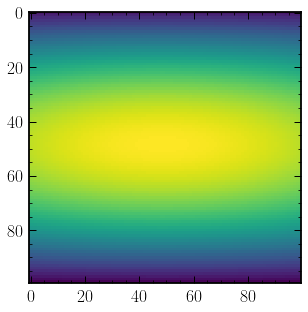

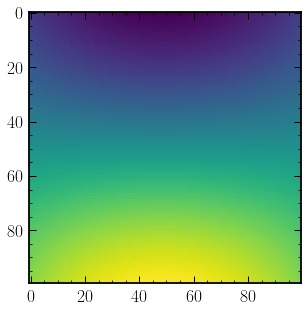

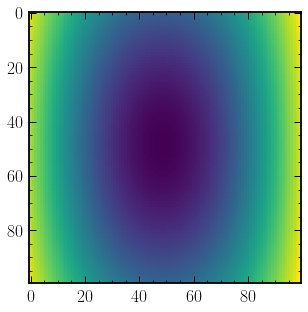

In [84]:
for sph_harm_temp in sph_harm_temps:
    plt.imshow(sph_harm_temp)
    plt.show()

In [ ]:
ll_list_sphharm = []
opt_list_sphharm = []
for dif in tqdm(dif_names[:]):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'ICS']:
        file = fits.open("/Users/smsharma/Downloads/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target ** 2)
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        phi /= 1e3
        
        if dif_type == 'pi0':
            for sph_harm_temp in sph_harm_temps:
                temp_ary.append(sph_harm_temp * phi[:, ::-1])
        else:
            temp_ary.append(phi[:, ::-1])


    temp_ary = np.array(temp_ary)
    
    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
    ll_data = - opt.fun
    
    opt_list_sphharm.append(opt)
    ll_list_sphharm.append(ll_data) 

 12%|█▎        | 10/80 [01:18<09:08,  7.83s/it]
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3418, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-85-314c3e747f77>", line 28, in <module>
    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py", line 617, in minimize
    return _minimize_lbfgsb(fun, x0, args, jac, bounds,
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/lbfgsb.py", line 360, in _minimize_lbfgsb
    f, g = func_and_grad(x)
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/_differentiable_functions.py", line 201, in fun_and_grad
    self._update_grad()
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/_differentiable_functions.py", line 171, in _up

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3418, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-85-314c3e747f77>", line 28, in <module>
    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py", line 617, in minimize
    return _minimize_lbfgsb(fun, x0, args, jac, bounds,
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/lbfgsb.py", line 360, in _minimize_lbfgsb
    f, g = func_and_grad(x)
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/_differentiable_functions.py", line 201, in fun_and_grad
    self._update_grad()
  File "/Users/smsharma/anaconda3/lib/python3.8/site-packages/scipy/optimize/_differentiable_functions.py", line 171, in _up

In [ ]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list_sphharm) * (~mask_roi).sum())
ax1.plot(np.array(ll_list) * (~mask_roi).sum(), ls='dotted', color=cols_default[0])
ax1.plot(np.array(ll_list_quadrants) * (~mask_roi).sum(), ls='dashed', color=cols_default[0])
ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='dashed')
ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls='dotted')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list_sphharm[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

## Skyfact

In [182]:
np.loadtxt("/Users/smsharma/Downloads/r5_map_mean_model_pi0i_2_20.dat").shape

(81, 360)

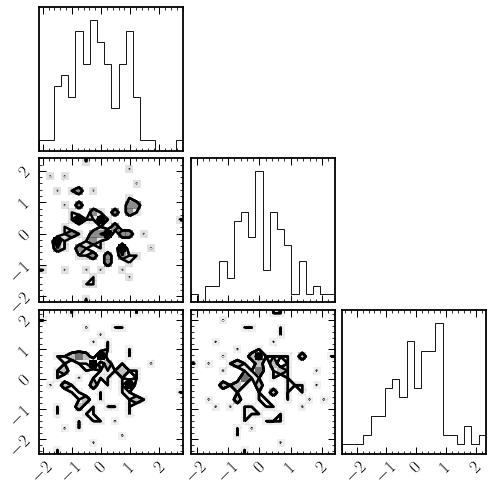

In [10]:
import corner

corner.corner(np.random.randn(100, 3));

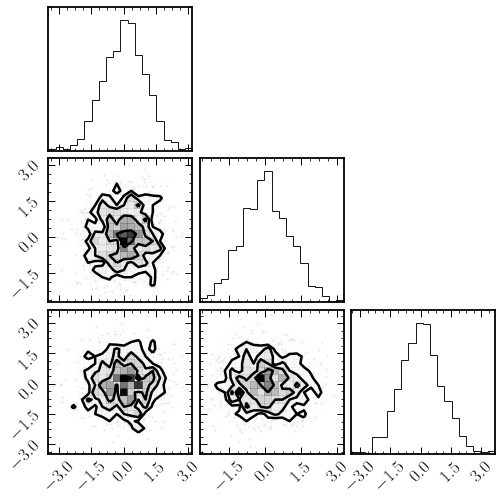

In [12]:
corner.corner(np.random.randn(1000, 3));